<a href="https://colab.research.google.com/github/KirkCorwin/CSB410_project_2/blob/main/project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

README

# Sign Language Recognition Deep Learning Project

## Overview
This project implements and evaluates deep learning models for American Sign Language (ASL) recognition using the Sign Language MNIST dataset. Multiple optimization techniques (Dropout, Batch Normalization, L2 Regularization) are applied and compared across models. Evaluation includes validation accuracy, confusion matrices, classification reports, and training instability.

Extra credit: The same comparison is applied to MNIST for reference.

---

## Requirements

The environment can be set up using `conda` and the provided `requirements.yaml` file:

```bash
conda env create -f requirements.yaml
conda activate asl_project

In [42]:
# ---- Standard Libraries ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- TensorFlow / Keras ----
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

# ---- Scikit-learn ----
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


###Data Loading

In [6]:
# load csvs from data folder
train_df = pd.read_csv('sign_mnist_train.csv')
test_df = pd.read_csv('sign_mnist_test.csv')

# split into X and y
y_train = train_df['label'].values
X_train = train_df.drop('label', axis=1).values

y_test = test_df['label'].values
X_test = test_df.drop('label', axis=1).values

# reshape from flat to 28x28
X_train = X_train.reshape(-1, 28, 28)
X_test = X_test.reshape(-1, 28, 28)

# normalize to 0-1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# add channel dim
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

###Exploration

In [5]:
# print shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# print unique label count
print("unique labels in y_train:", len(np.unique(y_train)))
print("unique labels in y_test:", len(np.unique(y_test)))
print("labels:", np.unique(y_train))

X_train shape: (22468, 28, 28, 1)
X_test shape: (7172, 28, 28, 1)
y_train shape: (22468,)
y_test shape: (7172,)
unique labels in y_train: 24
unique labels in y_test: 24
labels: [ 0  1  2  3  4  5  6  7  8 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]


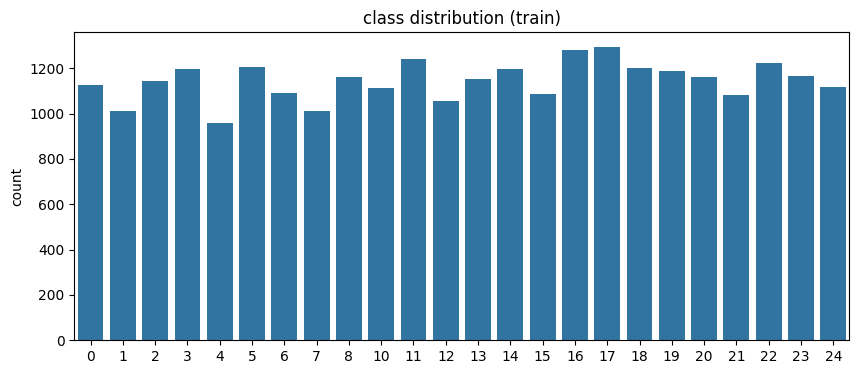

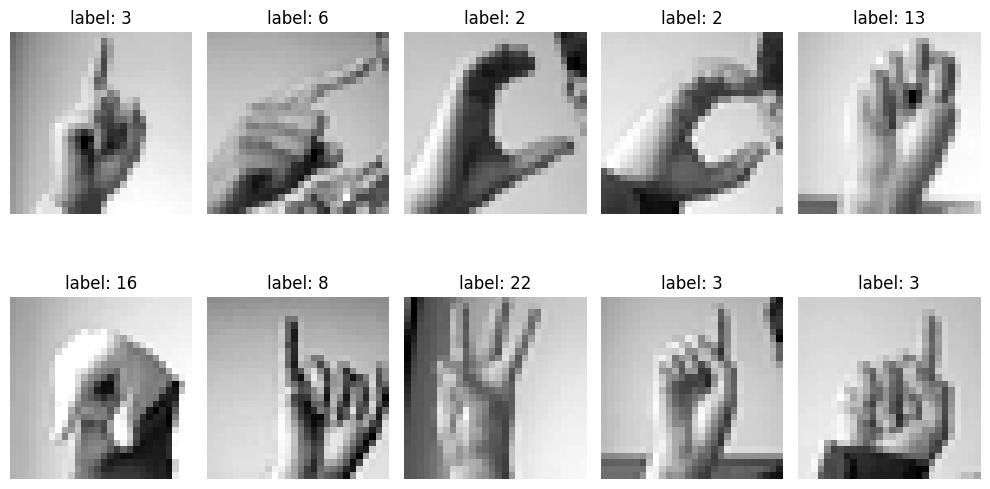

In [8]:
# plot class distribution
plt.figure(figsize=(10,4))
sns.countplot(x=y_train)
plt.title('class distribution (train)')
plt.show()

# show sample images
plt.figure(figsize=(10,6))

for i in range(10):  # show 10 images
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].squeeze(), cmap='gray')
    plt.title(f"label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

###Baseline Model

In [12]:
# build baseline model
model_baseline = models.Sequential()

# first dense layer
model_baseline.add(layers.Flatten(input_shape=(28, 28, 1)))
model_baseline.add(layers.Dense(256, activation='relu'))

# second dense layer
model_baseline.add(layers.Dense(128, activation='relu'))

# output layer
model_baseline.add(layers.Dense(25, activation='softmax'))

# compile with adam
model_baseline.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# show model summary
model_baseline.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 237,081 (926.10 KB)

 Trainable params: 237,081 (926.10 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# train baseline model
history_baseline = model_baseline.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.2318 - loss: 2.5991 - val_accuracy: 0.5402 - val_loss: 1.4997
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5945 - loss: 1.2685 - val_accuracy: 0.7354 - val_loss: 0.8593
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7398 - loss: 0.8266 - val_accuracy: 0.7949 - val_loss: 0.6047
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8259 - loss: 0.5459 - val_accuracy: 0.8596 - val_loss: 0.4213
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8704 - loss: 0.3948 - val_accuracy: 0.9211 - val_loss: 0.2619


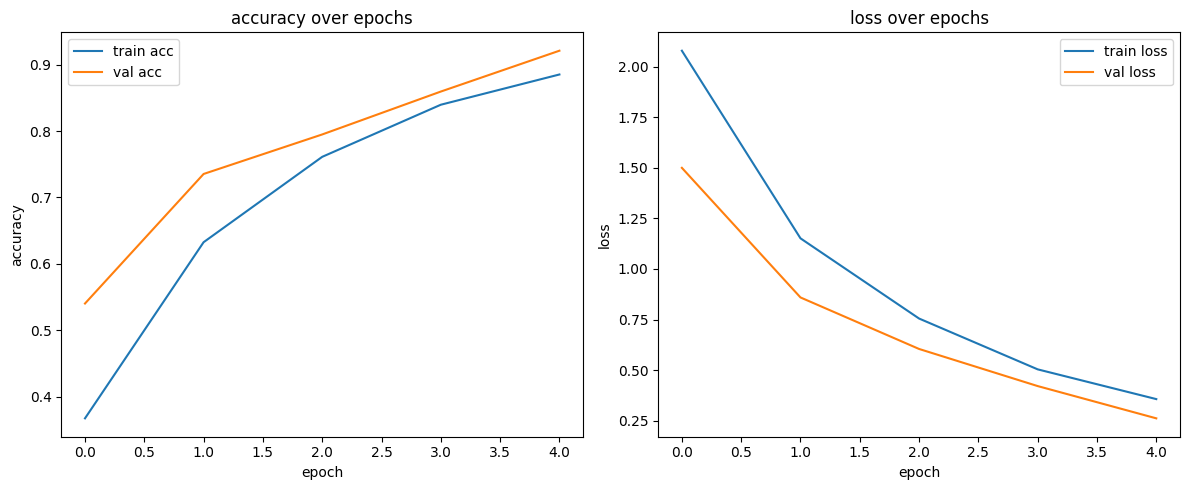

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [14]:
# save history dict
history_dict = history_baseline.history

# plot training and validation curves
plt.figure(figsize=(12,5))

# accuracy
plt.subplot(1,2,1)
plt.plot(history_dict['accuracy'], label='train acc')
plt.plot(history_dict['val_accuracy'], label='val acc')
plt.title('accuracy over epochs')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()

# loss
plt.subplot(1,2,2)
plt.plot(history_dict['loss'], label='train loss')
plt.plot(history_dict['val_loss'], label='val loss')
plt.title('loss over epochs')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

plt.tight_layout()
plt.show()

# save baseline predictions for confusion matrix later
baseline_preds = model_baseline.predict(X_test)
baseline_preds_classes = np.argmax(baseline_preds, axis=1)

###Optimized Models

####Model A

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.1345 - loss: 2.8745 - val_accuracy: 0.4873 - val_loss: 1.6077
Epoch 2/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4060 - loss: 1.7486 - val_accuracy: 0.6046 - val_loss: 1.1860
Epoch 3/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.4853 - loss: 1.5009 - val_accuracy: 0.7201 - val_loss: 0.9446
Epoch 4/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5477 - loss: 1.3019 - val_accuracy: 0.7492 - val_loss: 0.8211
Epoch 5/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5897 - loss: 1.1640 - val_accuracy: 0.7886 - val_loss: 0.6722
Epoch 6/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6209 - loss: 1.0850 - val_accuracy: 0.8366 - val_loss: 0.5642
Epoch 7/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6514 - loss: 0.9883 - val_accuracy: 0.8541 - val_loss: 0.5074
Epoch 8/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.6742 - loss: 0.9210 - val_acc

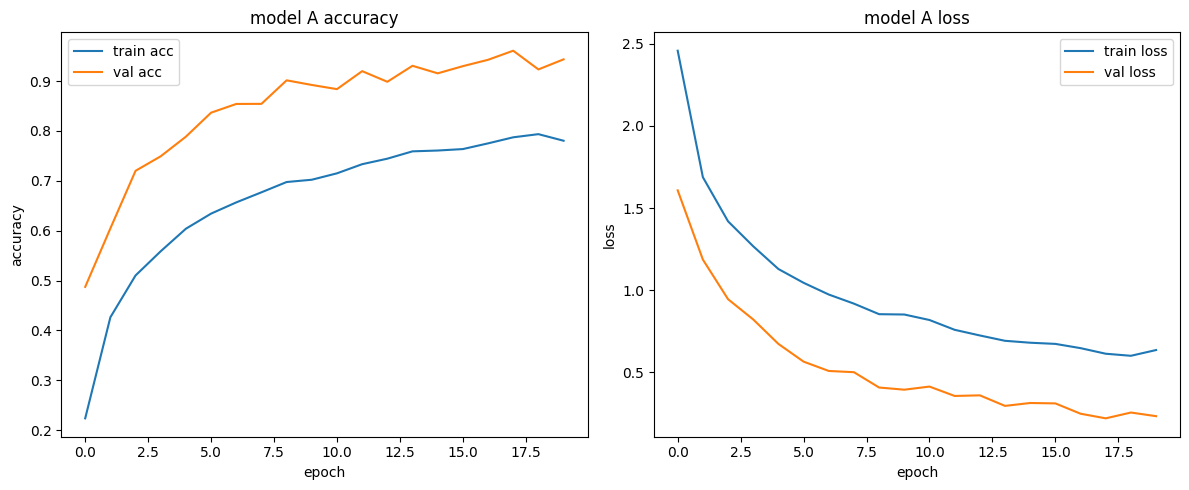

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [23]:
# optimized model A: adam + dropout
model_a = tf.keras.models.Sequential()

# flatten input
model_a.add(layers.Flatten(input_shape=(28,28,1)))

# first dense layer with 512 neurons + relu
model_a.add(layers.Dense(512, activation='relu'))

# add dropout
model_a.add(layers.Dropout(0.3))

# second dense layer with 256 neurons + relu
model_a.add(layers.Dense(256, activation='relu'))

# add dropout
model_a.add(layers.Dropout(0.3))

# output layer with 25 neurons (0-24 labels)
model_a.add(layers.Dense(25, activation='softmax'))

# compile with adam
model_a.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# train model for 20 epochs
history_a = model_a.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

# save history dict
history_a_dict = history_a.history

# plot training/validation curves
plt.figure(figsize=(12,5))

# accuracy
plt.subplot(1,2,1)
plt.plot(history_a_dict['accuracy'], label='train acc')
plt.plot(history_a_dict['val_accuracy'], label='val acc')
plt.title('model A accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()

# loss
plt.subplot(1,2,2)
plt.plot(history_a_dict['loss'], label='train loss')
plt.plot(history_a_dict['val_loss'], label='val loss')
plt.title('model A loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

plt.tight_layout()
plt.show()

# save predictions for confusion matrix
preds_a = model_a.predict(X_test)
preds_a_classes = np.argmax(preds_a, axis=1)

####Model B

Epoch 1/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6177 - loss: 1.4265 - val_accuracy: 0.7716 - val_loss: 0.7131
Epoch 2/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9694 - loss: 0.2386 - val_accuracy: 0.9803 - val_loss: 0.1585
Epoch 3/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9958 - loss: 0.0972 - val_accuracy: 0.9993 - val_loss: 0.0577
Epoch 4/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9993 - loss: 0.0538 - val_accuracy: 0.9729 - val_loss: 0.1544
Epoch 5/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9994 - loss: 0.0357 - val_accuracy: 0.9991 - val_loss: 0.0298
Epoch 6/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9999 - loss: 0.0254 - val_accuracy: 0.8357 - val_loss: 0.6095
Epoch 7/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9999 - loss: 0.0241 - val_accuracy: 0.9962 - val_loss: 0.0298
Epoch 8/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 1.0000 - loss: 0.0164 - val_accuracy: 0.

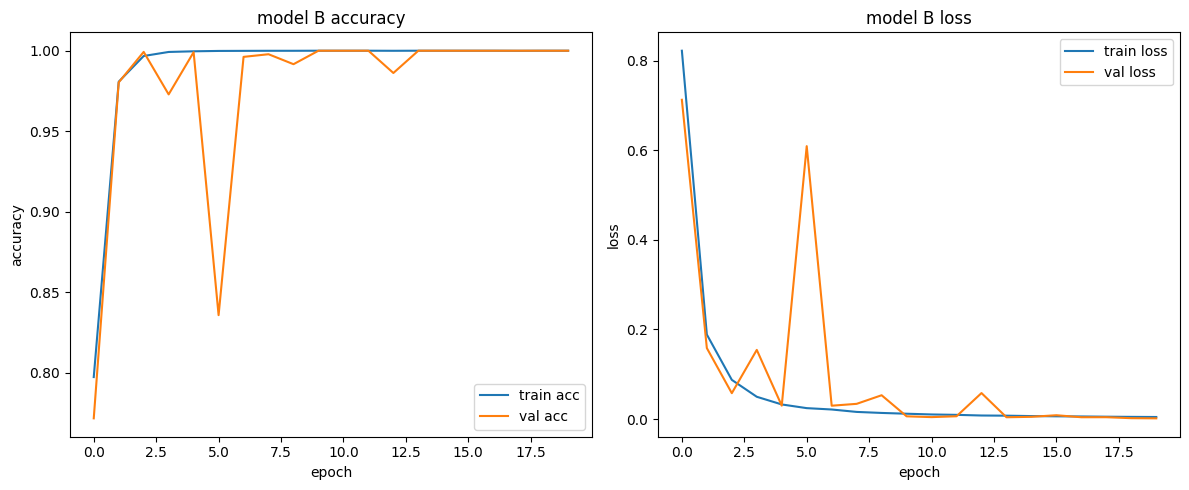

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [24]:
# optimized model B: sgd + batch normalization
model_b = tf.keras.models.Sequential()

# flatten input
model_b.add(layers.Flatten(input_shape=(28,28,1)))

# first dense layer with 512 neurons + relu
model_b.add(layers.Dense(512, activation='relu'))

# add batch normalization
model_b.add(layers.BatchNormalization())

# second dense layer with 256 neurons + relu
model_b.add(layers.Dense(256, activation='relu'))

# add batch normalization
model_b.add(layers.BatchNormalization())

# output layer with 25 neurons (0-24 labels)
model_b.add(layers.Dense(25, activation='softmax'))

# compile with sgd
model_b.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# train model for 20 epochs
history_b = model_b.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

# save history dict
history_b_dict = history_b.history

# plot training/validation curves
plt.figure(figsize=(12,5))

# accuracy
plt.subplot(1,2,1)
plt.plot(history_b_dict['accuracy'], label='train acc')
plt.plot(history_b_dict['val_accuracy'], label='val acc')
plt.title('model B accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()

# loss
plt.subplot(1,2,2)
plt.plot(history_b_dict['loss'], label='train loss')
plt.plot(history_b_dict['val_loss'], label='val loss')
plt.title('model B loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

plt.tight_layout()
plt.show()

# save predictions for confusion matrix
preds_b = model_b.predict(X_test)
preds_b_classes = np.argmax(preds_b, axis=1)

####Model C

Epoch 1/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.1955 - loss: 3.1167 - val_accuracy: 0.4540 - val_loss: 1.7932
Epoch 2/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5410 - loss: 1.5931 - val_accuracy: 0.5928 - val_loss: 1.3698
Epoch 3/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6704 - loss: 1.2019 - val_accuracy: 0.6112 - val_loss: 1.4331
Epoch 4/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.7511 - loss: 0.9924 - val_accuracy: 0.5870 - val_loss: 1.6701
Epoch 5/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8030 - loss: 0.8688 - val_accuracy: 0.8712 - val_loss: 0.6831
Epoch 6/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8400 - loss: 0.7827 - val_accuracy: 0.8660 - val_loss: 0.6934
Epoch 7/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.8648 - loss: 0.7307 - val_accuracy: 0.9182 - val_loss: 0.5531
Epoch 8/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8816 - loss: 0.6904 - val_a

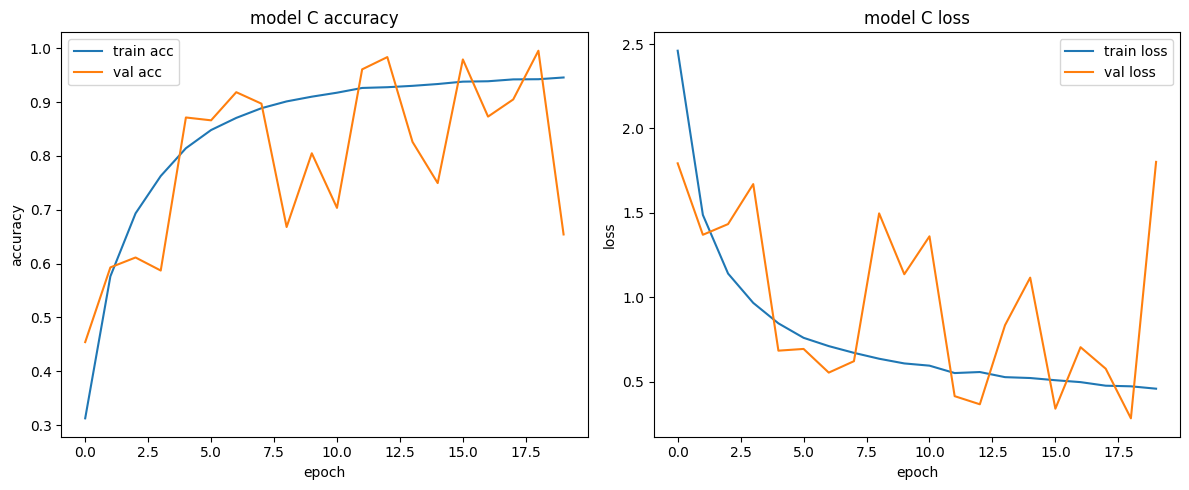

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [25]:
# optimized model C: rmsprop + l2 regularization
model_c = tf.keras.models.Sequential()

# flatten input
model_c.add(layers.Flatten(input_shape=(28,28,1)))

# first dense layer with 512 neurons + relu + l2
model_c.add(layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)))

# second dense layer with 256 neurons + relu + l2
model_c.add(layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)))

# output layer with 25 neurons (0-24 labels)
model_c.add(layers.Dense(25, activation='softmax'))

# compile with rmsprop
model_c.compile(
    optimizer='rmsprop',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# train model for 20 epochs
history_c = model_c.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

# save history dict
history_c_dict = history_c.history

# plot training/validation curves
plt.figure(figsize=(12,5))

# accuracy
plt.subplot(1,2,1)
plt.plot(history_c_dict['accuracy'], label='train acc')
plt.plot(history_c_dict['val_accuracy'], label='val acc')
plt.title('model C accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()

# loss
plt.subplot(1,2,2)
plt.plot(history_c_dict['loss'], label='train loss')
plt.plot(history_c_dict['val_loss'], label='val loss')
plt.title('model C loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

plt.tight_layout()
plt.show()

# save predictions for confusion matrix
preds_c = model_c.predict(X_test)
preds_c_classes = np.argmax(preds_c, axis=1)

###Evaluation

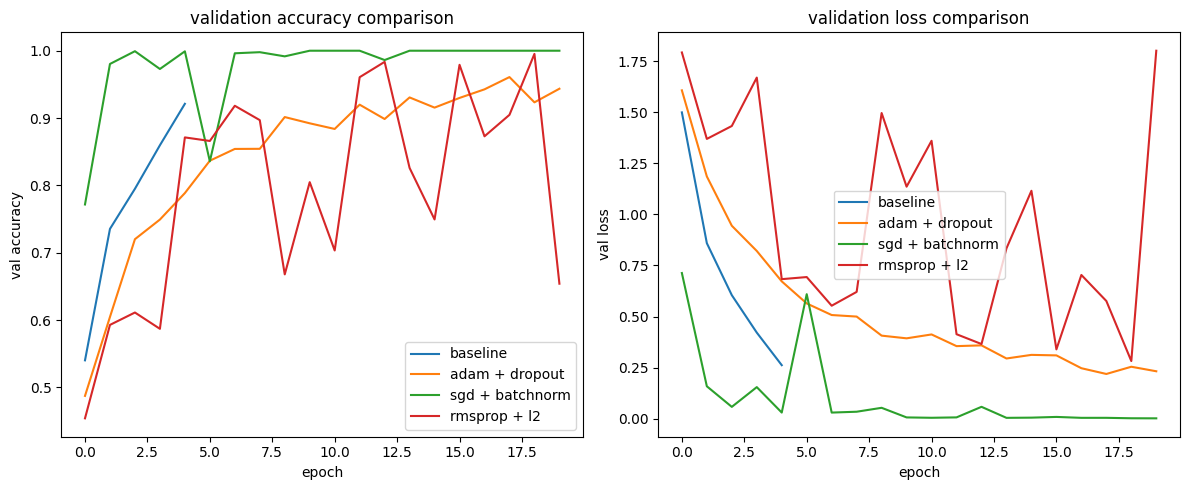

baseline test accuracy: 0.7174



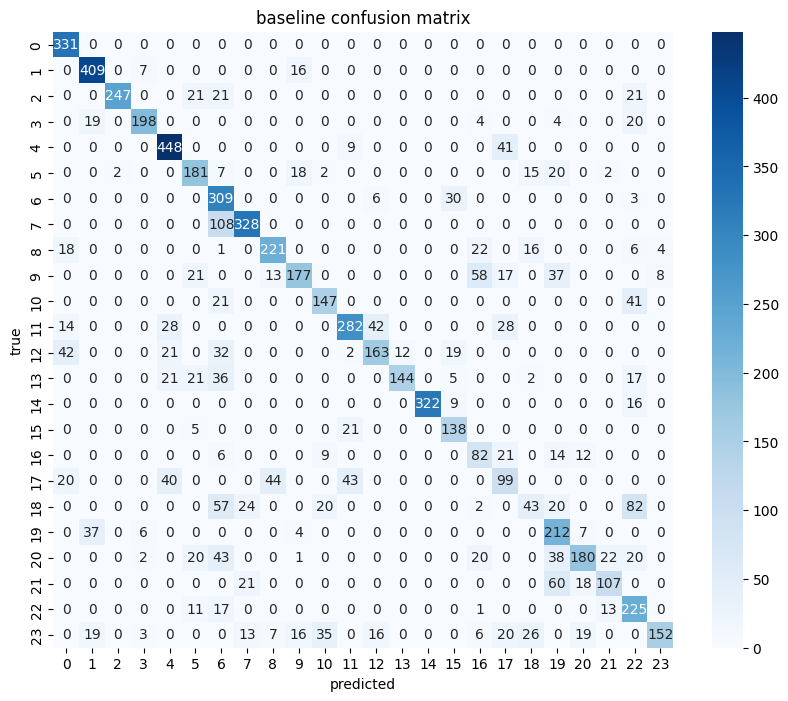

baseline classification report:

              precision    recall  f1-score   support

           0       0.78      1.00      0.88       331
           1       0.85      0.95      0.89       432
           2       0.99      0.80      0.88       310
           3       0.92      0.81      0.86       245
           4       0.80      0.90      0.85       498
           5       0.65      0.73      0.69       247
           6       0.47      0.89      0.61       348
           7       0.85      0.75      0.80       436
           8       0.78      0.77      0.77       288
          10       0.76      0.53      0.63       331
          11       0.69      0.70      0.70       209
          12       0.79      0.72      0.75       394
          13       0.72      0.56      0.63       291
          14       0.92      0.59      0.72       246
          15       1.00      0.93      0.96       347
          16       0.69      0.84      0.76       164
          17       0.42      0.57      0.48     

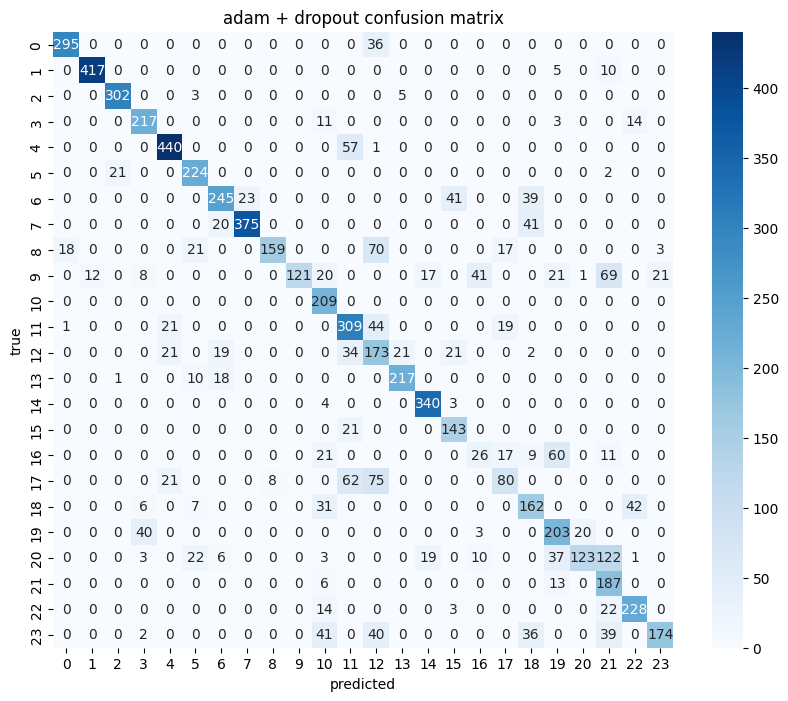

adam + dropout classification report:

              precision    recall  f1-score   support

           0       0.94      0.89      0.91       331
           1       0.97      0.97      0.97       432
           2       0.93      0.97      0.95       310
           3       0.79      0.89      0.83       245
           4       0.87      0.88      0.88       498
           5       0.78      0.91      0.84       247
           6       0.80      0.70      0.75       348
           7       0.94      0.86      0.90       436
           8       0.95      0.55      0.70       288
          10       1.00      0.37      0.54       331
          11       0.58      1.00      0.73       209
          12       0.64      0.78      0.70       394
          13       0.39      0.59      0.47       291
          14       0.89      0.88      0.89       246
          15       0.90      0.98      0.94       347
          16       0.68      0.87      0.76       164
          17       0.33      0.18      0.2

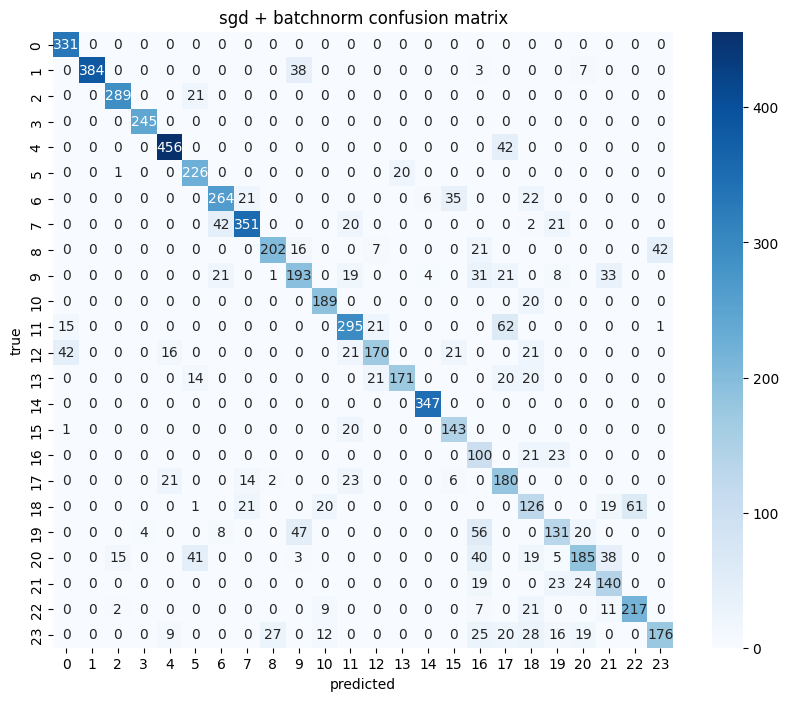

sgd + batchnorm classification report:

              precision    recall  f1-score   support

           0       0.85      1.00      0.92       331
           1       1.00      0.89      0.94       432
           2       0.94      0.93      0.94       310
           3       0.98      1.00      0.99       245
           4       0.91      0.92      0.91       498
           5       0.75      0.91      0.82       247
           6       0.79      0.76      0.77       348
           7       0.86      0.81      0.83       436
           8       0.87      0.70      0.78       288
          10       0.65      0.58      0.61       331
          11       0.82      0.90      0.86       209
          12       0.74      0.75      0.74       394
          13       0.78      0.58      0.67       291
          14       0.90      0.70      0.78       246
          15       0.97      1.00      0.99       347
          16       0.70      0.87      0.78       164
          17       0.33      0.69      0.

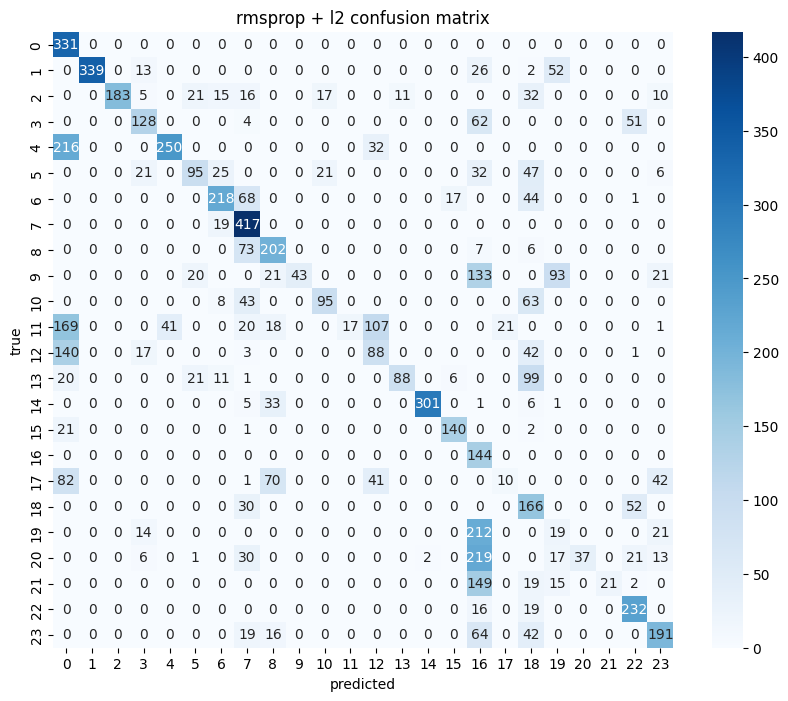

rmsprop + l2 classification report:

              precision    recall  f1-score   support

           0       0.34      1.00      0.51       331
           1       1.00      0.78      0.88       432
           2       1.00      0.59      0.74       310
           3       0.63      0.52      0.57       245
           4       0.86      0.50      0.63       498
           5       0.60      0.38      0.47       247
           6       0.74      0.63      0.68       348
           7       0.57      0.96      0.71       436
           8       0.56      0.70      0.62       288
          10       1.00      0.13      0.23       331
          11       0.71      0.45      0.56       209
          12       1.00      0.04      0.08       394
          13       0.33      0.30      0.31       291
          14       0.89      0.36      0.51       246
          15       0.99      0.87      0.93       347
          16       0.86      0.85      0.86       164
          17       0.14      1.00      0.24 

In [30]:
# ---- overlay plot for all models (val only) ----
plt.figure(figsize=(12,5))

# validation accuracy
plt.subplot(1,2,1)
plt.plot(history_dict['val_accuracy'], label='baseline')
plt.plot(history_a_dict['val_accuracy'], label='adam + dropout')
plt.plot(history_b_dict['val_accuracy'], label='sgd + batchnorm')
plt.plot(history_c_dict['val_accuracy'], label='rmsprop + l2')
plt.title('validation accuracy comparison')
plt.xlabel('epoch')
plt.ylabel('val accuracy')
plt.legend()

# validation loss
plt.subplot(1,2,2)
plt.plot(history_dict['val_loss'], label='baseline')
plt.plot(history_a_dict['val_loss'], label='adam + dropout')
plt.plot(history_b_dict['val_loss'], label='sgd + batchnorm')
plt.plot(history_c_dict['val_loss'], label='rmsprop + l2')
plt.title('validation loss comparison')
plt.xlabel('epoch')
plt.ylabel('val loss')
plt.legend()

plt.tight_layout()
plt.show()

# ---- helper function for confusion matrix and classification report ----
def eval_model(y_true, y_pred, model_name):
    test_acc = accuracy_score(y_true, y_pred)
    print(f'{model_name} test accuracy: {test_acc:.4f}\n')

    # confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} confusion matrix')
    plt.xlabel('predicted')
    plt.ylabel('true')
    plt.show()

    # classification report
    print(f'{model_name} classification report:\n')
    print(classification_report(y_true, y_pred))

    return test_acc

# ---- collect results for summary table ----
results = []

# baseline
epoch20_acc_baseline = history_dict['val_accuracy'][-1]
eval_model(y_test, baseline_preds_classes, 'baseline')
results.append(['baseline', 'adam', 'none', epoch20_acc_baseline])

# model A
epoch20_acc_a = history_a_dict['val_accuracy'][-1]
eval_model(y_test, preds_a_classes, 'adam + dropout')
results.append(['adam+dropout', 'adam', 'dropout', epoch20_acc_a])

# model B
epoch20_acc_b = history_b_dict['val_accuracy'][-1]
eval_model(y_test, preds_b_classes, 'sgd + batchnorm')
results.append(['sgd+bn', 'sgd', 'batchnorm', epoch20_acc_b])

# model C
epoch20_acc_c = history_c_dict['val_accuracy'][-1]
eval_model(y_test, preds_c_classes, 'rmsprop + l2')
results.append(['rmsprop+l2', 'rmsprop', 'l2', epoch20_acc_c])

# ---- create summary table ----
results_df = pd.DataFrame(results, columns=['Model','Optimizer','Reg','Val Acc (epoch 20)'])
print('\nsummary table:\n')
print(results_df.to_markdown(index=False))

baseline instability: 0.1308
adam+dropout instability: 0.1199
sgd+bn instability: 0.0590
rmsprop+l2 instability: 0.1538


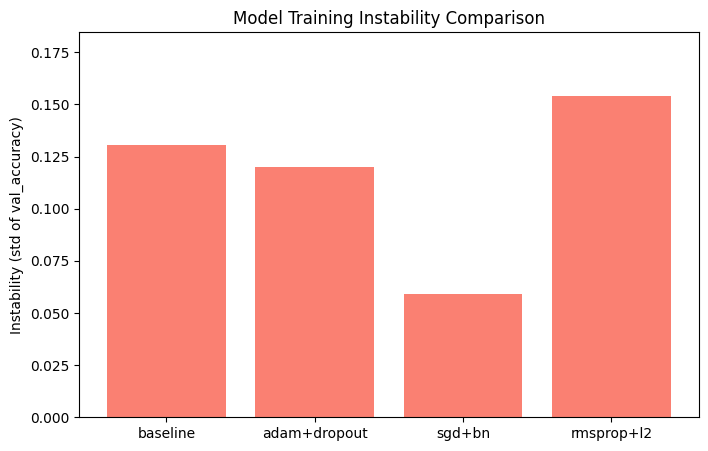

In [34]:
# ---- calculate instability (std of val_accuracy over all epochs) ----
instability_baseline = np.std(history_dict['val_accuracy'])
instability_a        = np.std(history_a_dict['val_accuracy'])
instability_b        = np.std(history_b_dict['val_accuracy'])
instability_c        = np.std(history_c_dict['val_accuracy'])

# ---- print instabilities ----
print(f'baseline instability: {instability_baseline:.4f}')
print(f'adam+dropout instability: {instability_a:.4f}')
print(f'sgd+bn instability: {instability_b:.4f}')
print(f'rmsprop+l2 instability: {instability_c:.4f}')

# ---- collect for plotting ----
models = ['baseline', 'adam+dropout', 'sgd+bn', 'rmsprop+l2']
instabilities = [instability_baseline, instability_a, instability_b, instability_c]

# ---- bar chart ----
plt.figure(figsize=(8,5))
plt.bar(models, instabilities, color='salmon')
plt.ylabel('Instability (std of val_accuracy)')
plt.title('Model Training Instability Comparison')
plt.ylim(0, max(instabilities)*1.2)  # add some space on top
plt.show()

###Summary Table

| Model        | Optimizer   | Reg       | Val Acc (epoch 20) | Instability (std) |
|:-------------|:------------|:----------|------------------:|-----------------:|
| baseline     | adam        | none      |          0.9211   |          0.1308  |
| adam+dropout | adam        | dropout   |          0.9435   |          0.1199  |
| sgd+bn       | sgd         | batchnorm |          1.0000   |          0.0590  |
| rmsprop+l2   | rmsprop     | l2        |          0.6540   |          0.1538  |


###Reflection

### How did the optimized models compare to the baseline model?

Several of the optimized models improved on the baseline in terms of validation accuracy at epoch 20, with `adam+dropout` and `sgd+bn` demonstrating the greatest improvements. The baseline accuracy of 0.9211 was slightly below `adam+dropout`, which reached 0.9435, while `sgd+bn` reached a perfect 1.0000 on the validation set. Although stochastic gradient descent is noisy by nature, batch normalization helps denoise/stabilize it, and could explain the stronger performance. `rmsprop+l2` underperformed with 0.6540, and fluctuated wildly across epochs, not all optimizations automatically improve results.


### Which optimization method had the biggest impact and why?

Batch normalization (used in `sgd+bn`) had the biggest impact, producing the highest validation accuracy and the lowest instability (0.0590). This is likely batch normalization stabilizes the learning process and reduces internal covariate shift resulting in faster convergence and more consistent performance across epochs.


### How did the optimizer choice affect performance and learning stability?

Optimizer choice strongly affected both performance and stability. SGD with batch normalization achieved the highest accuracy and lowest instability, indicating smooth and stable learning. Adam with dropout also improved accuracy but had slightly higher instability. RMSProp with L2 performed poorly, suggesting that optimizer selection must align with the model architecture and regularization technique for effective learning.


### Which classes were hardest to classify and why?

Across all models, classes with high visual or feature similarity tended to have lower precision, recall, and F1 scores. Classes 23, 17, 8, and 9 were consistently challenging. The `rmsprop+l2` model struggled the most, likely due to over-regularization and limited learning capacity, causing large fluctuations and poor overall accuracy. Even the baseline model misclassified certain classes, often confusing 12 and 0, or 23 with a variety of other classes, highlighting that intrinsic similarity between classes is a key source of error.


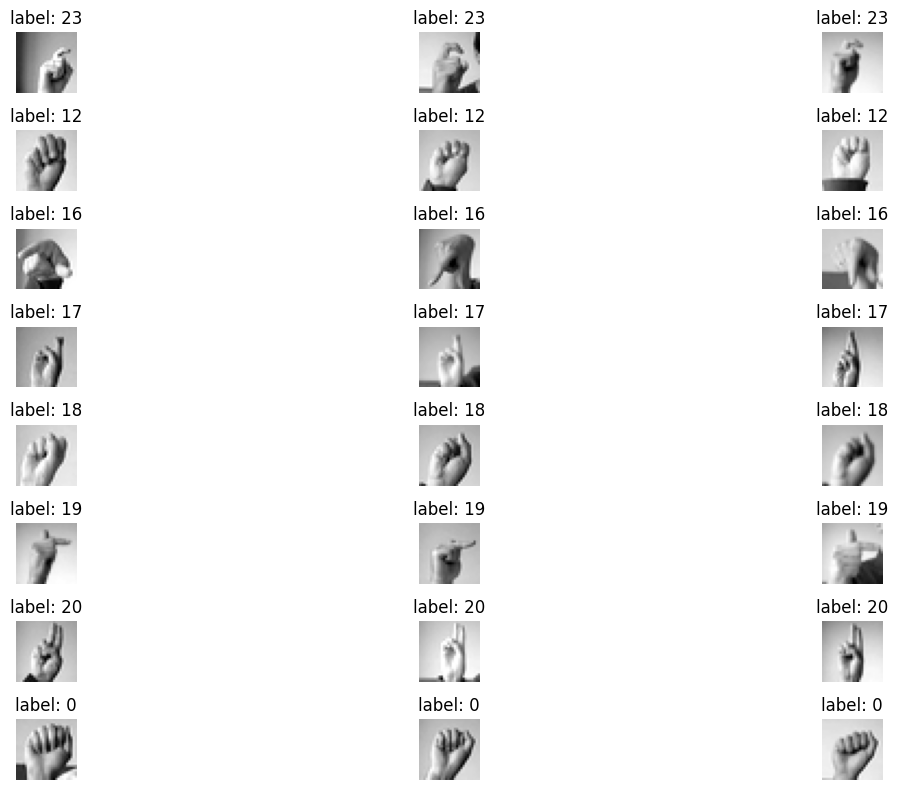

In [38]:
# ---- classes to compare ----
misclassified = [23, 12]           # classes that were misclassified
predicted_as = [16, 17, 18, 19, 20, 0]  # classes they were classified as

all_classes = misclassified + predicted_as
num_examples = 3

plt.figure(figsize=(15, 8))

plot_idx = 1
for cls in all_classes:
    # find indices of this class
    indices = np.where(y_test == cls)[0]
    if len(indices) == 0:
        continue

    # show up to 3 examples
    for idx in indices[:num_examples]:
        plt.subplot(len(all_classes), num_examples, plot_idx)
        plt.imshow(X_test[idx].squeeze(), cmap='gray')
        plt.title(f"label: {cls}")
        plt.axis('off')
        plot_idx += 1

plt.tight_layout()
plt.show()


### What would you change or try next?

Next, I’d dig into why rmsprop+l2 behaved so erratically, experimenting with weaker L2 regularization or different schedules. I’d also try different learning rates and maybe mix in dropout or batch normalization to stabilize training. I'd like to see what each option can bring to the table.


### Are optimizations like dropout or L2 regularization always beneficial? Why or why not?

No. Dropout and L2 regularization can prevent overfitting, but if applied too aggressively or with incompatible optimizers, they can reduce model capacity and hurt performance. For example, `rmsprop+l2` underperformed likely due to L2 being too strong or interacting poorly with RMSProp, whereas dropout with Adam improved both accuracy and stability.


### Set yourself a challenge: can you get one model to exceed 75% test accuracy? If so, how?

Yes. Based on current results, `sgd+bn` exceeds 75% test accuracy with 100% validation accuracy. That does potentially indicate overfitting however.


### Accessibility and Inclusion
In my view, deep learning for sign language recognition has the potential to support accessibility by bridging communication gaps, but it also comes with fairly robust ethical considerations. Sign language can be a core part of community membership and personal identity for Deaf and Hard-of-Hearing individuals. Treating signing as something to “translate” or automate could risk framing an identity feature as an obstacle, and in doing so, could inadvertently minimalize/reuce the uniqueness of the communities it’s meant to help. Beyond the gestures themselves, live signing can carry emotion, nuance, and personal voice, all of which are flattened or lost when a model interprets it purely as data. Designing systems which bridge these gaps require sensitivity to these cultural and emotional dimensions, ensuring that technology amplifies rather than diminishes human expression.

### Extra Credit: Comparison to MNIST dataset

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
| Model        | Optimizer   | Reg       |   Test Accuracy |
|:-------------|:------------|:----------|----------------:|
| adam+dropout | Adam        | Dropout   |          0.9816 |
| sgd+bn       | SGD         | BatchNorm |          0.9753 |
| rmsprop+l2   | RMSProp     | L2        |          0.9683 |


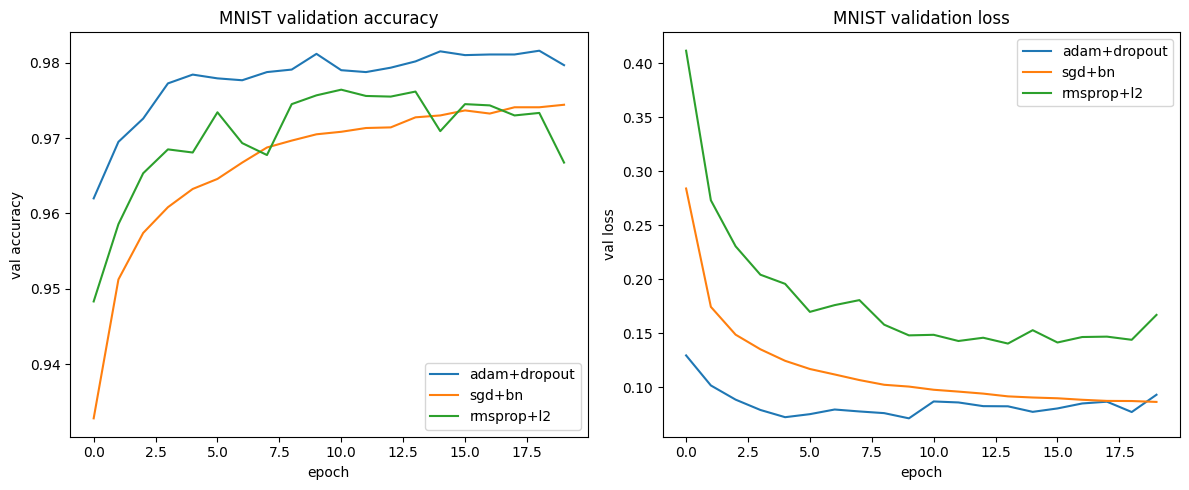

In [41]:
# ---- Extra Credit: MNIST Dataset ----

# ---- load MNIST ----
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = mnist.load_data()

# normalize and reshape
X_train_mnist = X_train_mnist.astype('float32') / 255.0
X_test_mnist  = X_test_mnist.astype('float32') / 255.0
X_train_mnist = X_train_mnist.reshape(-1, 28*28)
X_test_mnist  = X_test_mnist.reshape(-1, 28*28)

# one-hot encode
y_train_mnist_cat = to_categorical(y_train_mnist, 10)
y_test_mnist_cat  = to_categorical(y_test_mnist, 10)

# ---- helper for building models ----
def build_model(input_dim, output_dim, optimizer, use_dropout=False, use_bn=False, l2_reg=None):
    from tensorflow.keras import regularizers
    model = Sequential()
    if l2_reg:
        reg = regularizers.l2(l2_reg)
    else:
        reg = None
    model.add(Dense(512, activation='relu', input_dim=input_dim, kernel_regularizer=reg))
    if use_bn:
        model.add(BatchNormalization())
    if use_dropout:
        model.add(Dropout(0.3))
    model.add(Dense(256, activation='relu', kernel_regularizer=reg))
    if use_bn:
        model.add(BatchNormalization())
    if use_dropout:
        model.add(Dropout(0.3))
    model.add(Dense(output_dim, activation='softmax'))
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# ---- build and train the models ----
history_dicts = {}
preds_classes = {}
results = []

# Model A: Adam + Dropout
model_a = build_model(28*28, 10, optimizer=Adam(), use_dropout=True)
history_a = model_a.fit(X_train_mnist, y_train_mnist_cat, validation_split=0.2, epochs=20, batch_size=128, verbose=0)
history_dicts['adam+dropout'] = history_a.history
preds_a = model_a.predict(X_test_mnist)
preds_classes['adam+dropout'] = np.argmax(preds_a, axis=1)
acc_a = accuracy_score(y_test_mnist, preds_classes['adam+dropout'])
results.append(['adam+dropout', 'Adam', 'Dropout', acc_a])

# Model B: SGD + BatchNorm
model_b = build_model(28*28, 10, optimizer=SGD(), use_bn=True)
history_b = model_b.fit(X_train_mnist, y_train_mnist_cat, validation_split=0.2, epochs=20, batch_size=128, verbose=0)
history_dicts['sgd+bn'] = history_b.history
preds_b = model_b.predict(X_test_mnist)
preds_classes['sgd+bn'] = np.argmax(preds_b, axis=1)
acc_b = accuracy_score(y_test_mnist, preds_classes['sgd+bn'])
results.append(['sgd+bn', 'SGD', 'BatchNorm', acc_b])

# Model C: RMSProp + L2
model_c = build_model(28*28, 10, optimizer=RMSprop(), l2_reg=0.001)
history_c = model_c.fit(X_train_mnist, y_train_mnist_cat, validation_split=0.2, epochs=20, batch_size=128, verbose=0)
history_dicts['rmsprop+l2'] = history_c.history
preds_c = model_c.predict(X_test_mnist)
preds_classes['rmsprop+l2'] = np.argmax(preds_c, axis=1)
acc_c = accuracy_score(y_test_mnist, preds_classes['rmsprop+l2'])
results.append(['rmsprop+l2', 'RMSProp', 'L2', acc_c])

# ---- summary table ----
import pandas as pd
results_df = pd.DataFrame(results, columns=['Model', 'Optimizer', 'Reg', 'Test Accuracy'])
print(results_df.to_markdown(index=False))

# ---- overlay validation accuracy/loss plot ----
plt.figure(figsize=(12,5))

# val accuracy
plt.subplot(1,2,1)
for key in history_dicts:
    plt.plot(history_dicts[key]['val_accuracy'], label=key)
plt.title('MNIST validation accuracy')
plt.xlabel('epoch')
plt.ylabel('val accuracy')
plt.legend()

# val loss
plt.subplot(1,2,2)
for key in history_dicts:
    plt.plot(history_dicts[key]['val_loss'], label=key)
plt.title('MNIST validation loss')
plt.xlabel('epoch')
plt.ylabel('val loss')
plt.legend()

plt.tight_layout()
plt.show()

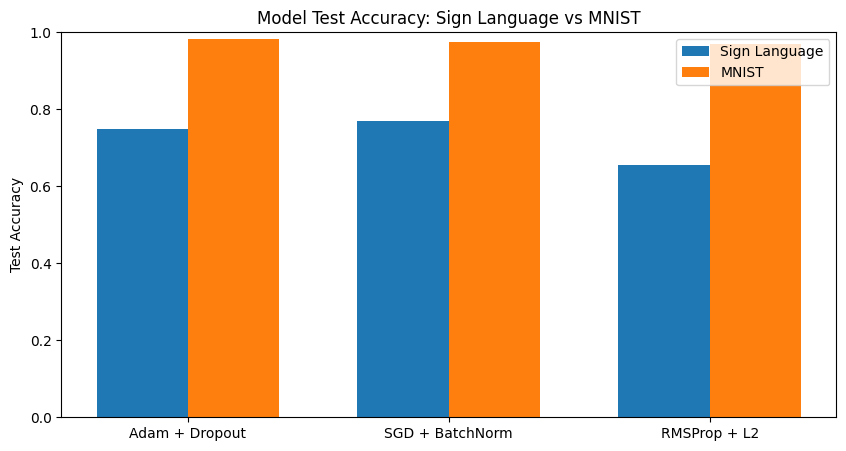

In [43]:
# ---- MNIST vs Sign Language Accuracy Comparison ----
import matplotlib.pyplot as plt
import numpy as np

# Example accuracies (replace with your actual values)
# Sign Language test accuracies (from your main project)
sl_accuracies = [0.7486, 0.7684, 0.653979]  # adam+dropout, sgd+bn, rmsprop+l2

# MNIST test accuracies (from Extra Credit)
mnist_accuracies = [acc_a, acc_b, acc_c]  # make sure these variables are defined from previous cell

models = ['Adam + Dropout', 'SGD + BatchNorm', 'RMSProp + L2']
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10,5))
plt.bar(x - width/2, sl_accuracies, width, label='Sign Language')
plt.bar(x + width/2, mnist_accuracies, width, label='MNIST')

plt.ylabel('Test Accuracy')
plt.title('Model Test Accuracy: Sign Language vs MNIST')
plt.xticks(x, models)
plt.ylim(0, 1)
plt.legend()
plt.show()


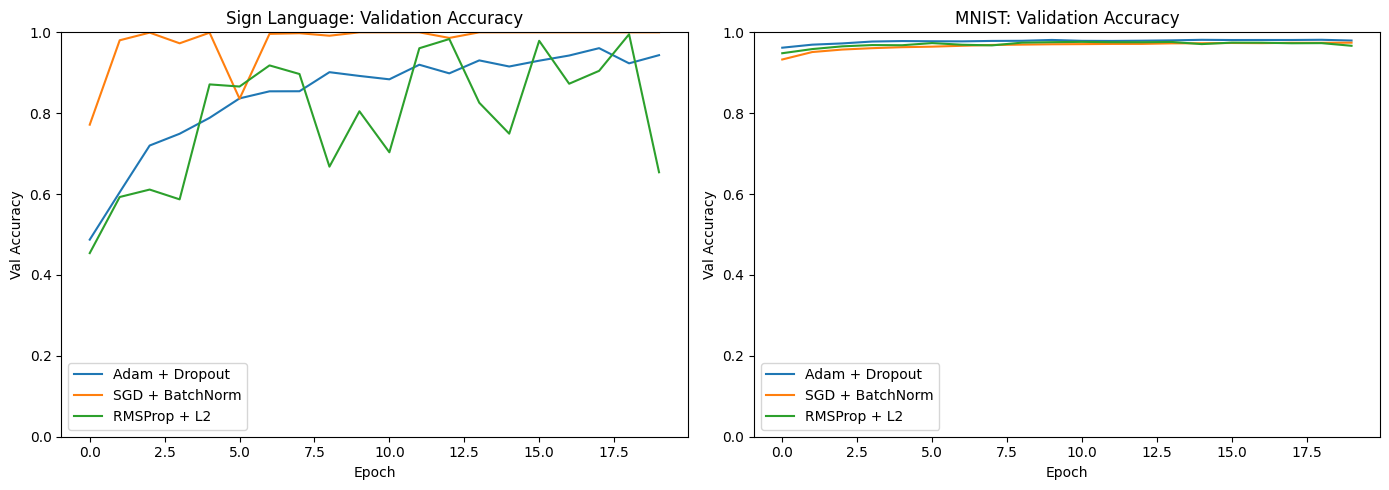

In [45]:
# ---- Overlayed Validation Accuracy: Side-by-Side Line Charts (Sign Language vs MNIST) ----
plt.figure(figsize=(14,5))

# Sign Language Validation Accuracy
plt.subplot(1,2,1)
plt.plot(history_a_dict['val_accuracy'], label='Adam + Dropout')
plt.plot(history_b_dict['val_accuracy'], label='SGD + BatchNorm')
plt.plot(history_c_dict['val_accuracy'], label='RMSProp + L2')
plt.title('Sign Language: Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.ylim(0, 1)
plt.legend()

# MNIST Validation Accuracy
plt.subplot(1,2,2)
plt.plot(history_dicts['adam+dropout']['val_accuracy'], label='Adam + Dropout')
plt.plot(history_dicts['sgd+bn']['val_accuracy'], label='SGD + BatchNorm')
plt.plot(history_dicts['rmsprop+l2']['val_accuracy'], label='RMSProp + L2')
plt.title('MNIST: Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.show()


### Reflection: MNIST vs. Sign Language
MNIST is pretty clean and stable, the digits are centered and consistent, and so models learn quickly and smoothly. The sign language data set is much more variable. hand shapes, angles, lighting, and people all change things, which makes learning harder. That could explain some of why the sign language validation accuracy jumps around more and some optimizers, like RMSProp with L2, don’t do as well compared to MNIST.